SESSION 14 - Exploratory Data Analysis (EDA) (Part 1)Topics Covered:What is EDA & why it's criticalUnivariate analysisnumerical vs categoricalBivariate
analysiscorrelationscatterplotsgroupby analysisMultivariate analysispairplotheatmapldentifying data patternsDetecting feature relationships


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



TASKS



1. Download a small dataset of IPL cricket matches (CSV or Excel), load it into a pandas DataFrame, and perform univariate analysis by printing the summary statistics (mean, median, min, max, std) for the 'total_runs'
column.


In [3]:
ipl_dataset = pd.read_csv("F:\Tops_assignment\Python_Library\datasets\ipl\deliveries.csv")
ipl_dataset["total_runs"].describe()

count    260911.000000
mean          1.332834
std           1.626435
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           7.000000
Name: total_runs, dtype: float64

In [6]:
ipl_dataset["total_runs"]

0         NaN
1         0.0
2         NaN
3         0.0
4         0.0
         ... 
260915    1.0
260916    1.0
260917    1.0
260918    1.0
260919    1.0
Name: total_runs, Length: 260920, dtype: float64

In [5]:
summary = {
    "Mean": ipl_dataset["total_runs"].mean(),
    "Median": ipl_dataset["total_runs"].median(),
    "Minimum": ipl_dataset["total_runs"].min(),
    "Maximum": ipl_dataset["total_runs"].max(),
    "Standard Deviation": ipl_dataset["total_runs"].std()
}

print(summary)

{'Mean': np.float64(1.3328338015645183), 'Median': 1.0, 'Minimum': 0.0, 'Maximum': 7.0, 'Standard Deviation': 1.6264348676048004}



2. Using a dataset of Flipkart product reviews (at least columns: 'rating', 'category'), create a bar plot showing the count of reviews for each rating (1-5 stars) using matplotlib or seaborn.


In [8]:
flipkart_data = pd.read_excel("F:/Tops_assignment/Python_Library/datasets/flipkart_product_excel/flipkart_product_listings_10000.xlsx")

In [9]:
flipkart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    10000 non-null  object 
 1   Product_Name  10000 non-null  object 
 2   Category      10000 non-null  object 
 3   Brand         10000 non-null  object 
 4   Price_INR     10000 non-null  int64  
 5   Rating        10000 non-null  float64
 6   Reviews       10000 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 547.0+ KB


<Axes: xlabel='Rating', ylabel='Reviews'>

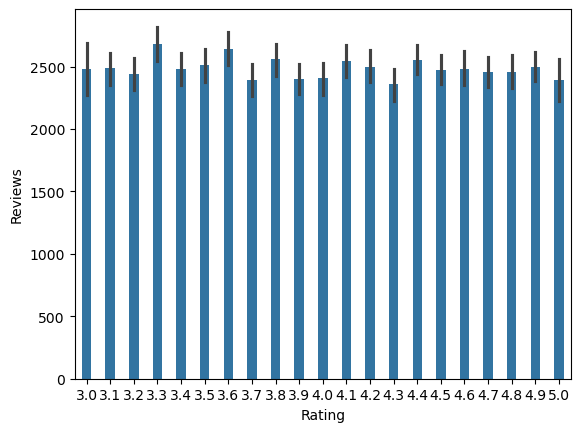

In [14]:
sns.barplot(flipkart_data , x = "Rating" , y = "Reviews" , width= 0.4 )


3. Take a dataset of Zomato restaurant listings (with 'average_cost_for_two' and 'user_rating' columns) and create a scatterplot to visualize the relationship between cost and user rating.

        Hint: Use seaborn's scatterplot() function and label the axes clearly.


In [15]:
zomato_dataset = pd.read_csv("F:\Tops_assignment\Python_Library\datasets\zomato.csv\zomato.csv")

In [16]:
zomato_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

<Axes: xlabel='approx_cost(for two people)', ylabel='rate'>

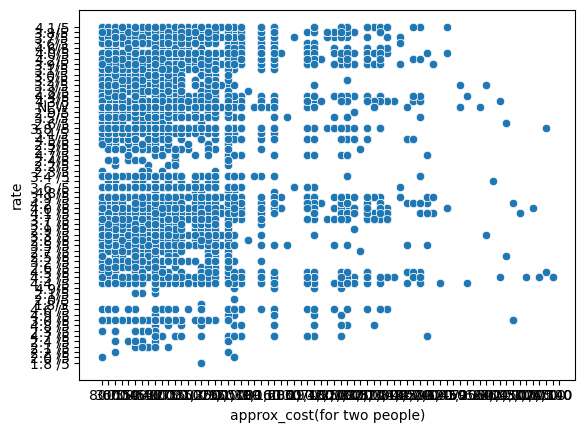

In [18]:
sns.scatterplot(zomato_dataset , x = "approx_cost(for two people)" , y = "rate")


4. For a BookMyShow movie dataset (with 'genre' and 'box_office_collection' columns), use groupby analysis to find the average box office collection for each genre and display the results as a sorted table.


In [22]:
book_by_show = pd.read_csv("F:/Tops_assignment/Python_Library/datasets/bookmyshow_movies.csv")

In [23]:
book_by_show.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   movie_id               400 non-null    int64  
 1   title                  400 non-null    object 
 2   genre                  400 non-null    object 
 3   language               400 non-null    object 
 4   certification          400 non-null    object 
 5   release_year           400 non-null    int64  
 6   runtime_mins           400 non-null    int64  
 7   box_office_collection  400 non-null    float64
 8   budget_cr              400 non-null    float64
 9   imdb_rating            400 non-null    float64
 10  screens                400 non-null    int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 34.5+ KB


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Action'),
  Text(1, 0, 'Drama'),
  Text(2, 0, 'Sci-Fi'),
  Text(3, 0, 'Comedy'),
  Text(4, 0, 'Horror'),
  Text(5, 0, 'Romance'),
  Text(6, 0, 'Biography'),
  Text(7, 0, 'Thriller'),
  Text(8, 0, 'Adventure'),
  Text(9, 0, 'Animation')])

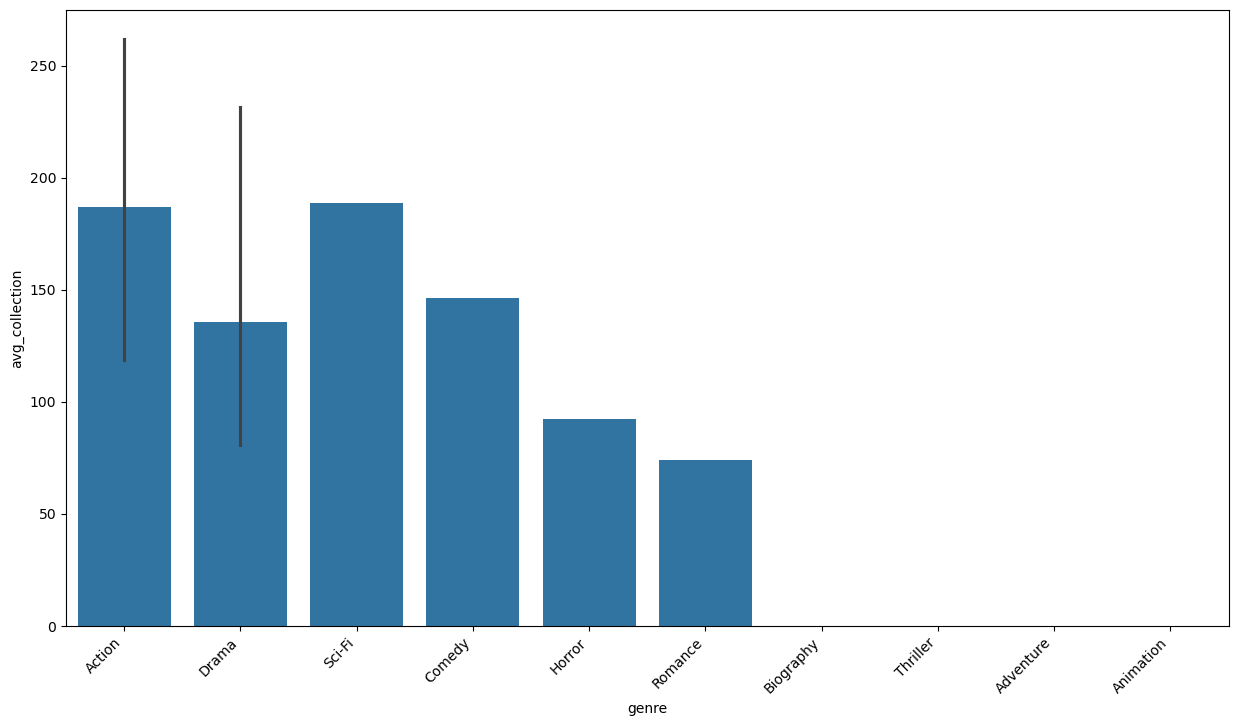

In [34]:
avg_collection = (

    book_by_show.groupby("genre")["box_office_collection"].mean().sort_values(ascending=False).reset_index()
)

book_by_show["avg_collection"] = avg_collection["box_office_collection"]
plt.figure(figsize=(15, 8))
sns.barplot(book_by_show , x = "genre" , y = "avg_collection")
plt.xticks(rotation=45, ha="right", fontsize=10)


5. Use the seaborn 'pairplot' function on a Spotify songs dataset (with at least 'danceability', 'energy', 'valence', and 'popularity' columns) to visualize pairwise relationships between these features. Briefly describe one
interesting pattern you observe.

In [33]:
spotify_dataset = pd.read_csv("F:\Tops_assignment\Python_Library\datasets\spotify_songs.csv")

In [38]:
spotify_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   track_id      600 non-null    object 
 1   genre         600 non-null    object 
 2   danceability  600 non-null    float64
 3   energy        600 non-null    float64
 4   valence       600 non-null    float64
 5   popularity    600 non-null    int64  
 6   tempo         600 non-null    float64
 7   loudness      600 non-null    float64
 8   speechiness   600 non-null    float64
 9   acousticness  600 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 47.0+ KB


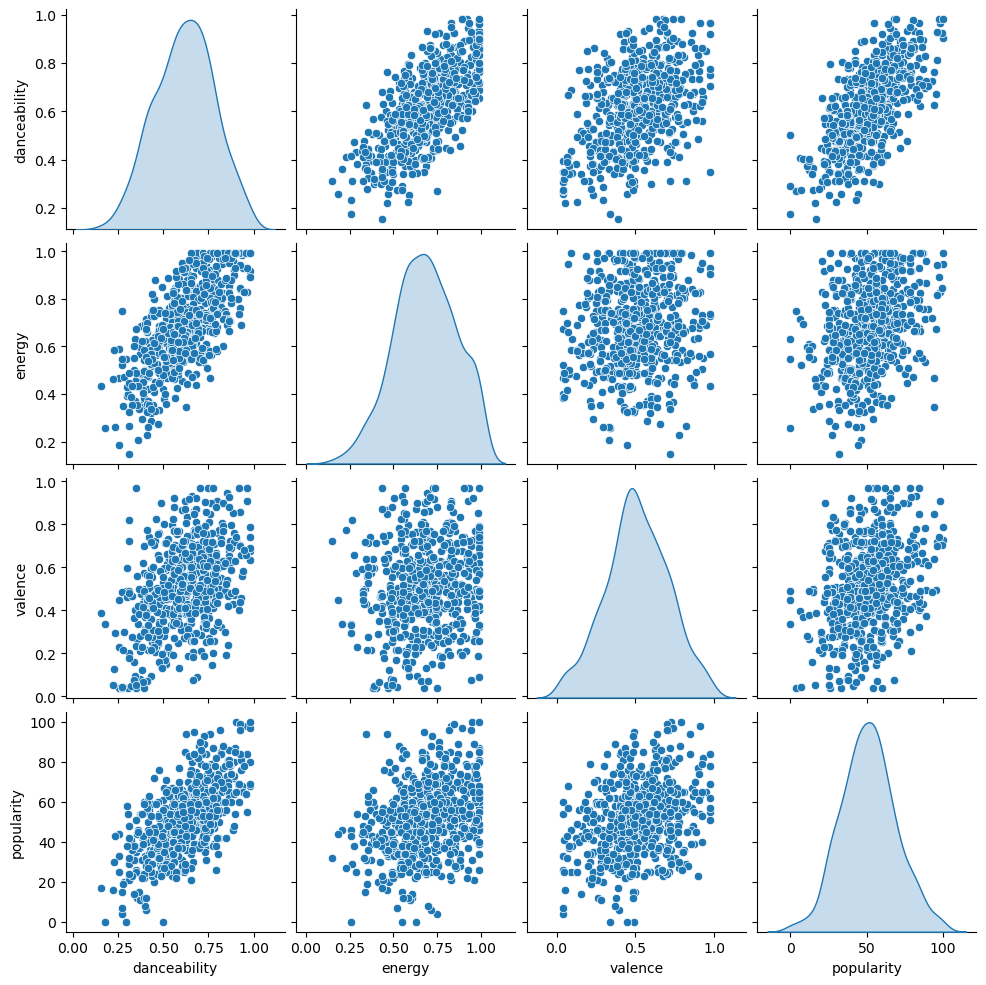

In [43]:
sns.pairplot(spotify_dataset[["danceability", "energy", "valence", "popularity"]] , diag_kind= "kde")